In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../src/data/2023_Spain_FP2_laps.csv')

Conversión inicial de los tiempos

In [3]:
time_cols = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']

def str_to_timedelta(time_str):
    if pd.isna(time_str):
        return pd.NaT
    parts = time_str.split(':') 
    if len(parts) == 3:
        min, sec, ms = map(int, parts)
        return pd.Timedelta(minutes=min, seconds=sec, milliseconds=ms)
    return pd.NaT

for col in time_cols:
    df[col] = df[col].apply(str_to_timedelta)
df_secs = df[time_cols].apply(lambda x: x.dt.total_seconds())

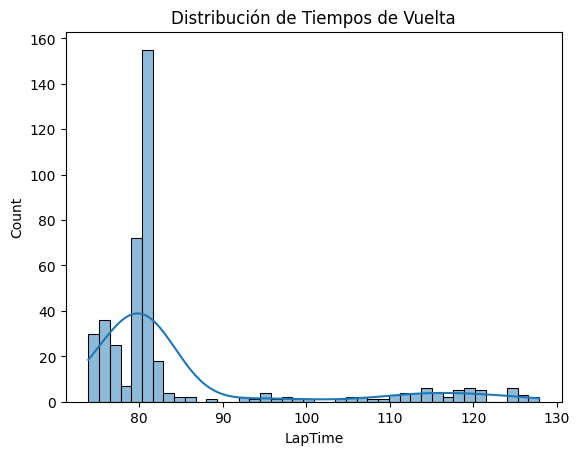

In [8]:
sns.histplot(df['LapTime'].dt.total_seconds(), kde=True)
plt.title('Distribución de Tiempos de Vuelta')
plt.show()

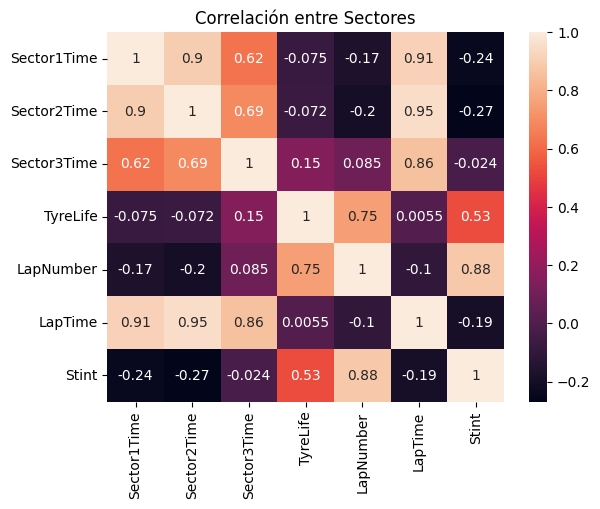

In [9]:
corr = df[['Sector1Time', 'Sector2Time', 'Sector3Time', 'TyreLife', 'LapNumber', 'LapTime', 'Stint']].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlación entre Sectores')
plt.show()

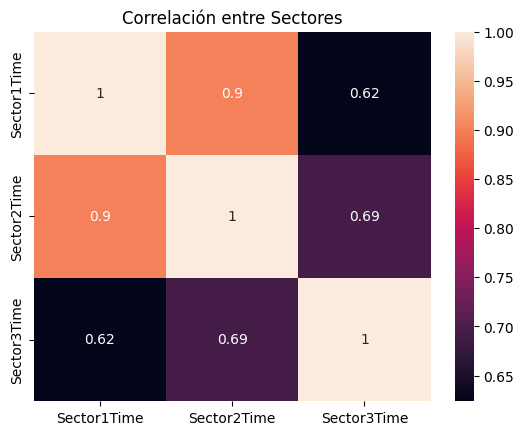

In [10]:
corr = df[['Sector1Time', 'Sector2Time', 'Sector3Time']].apply(lambda x: x.dt.total_seconds()).corr()
sns.heatmap(corr, annot=True)
plt.title('Correlación entre Sectores')
plt.show()

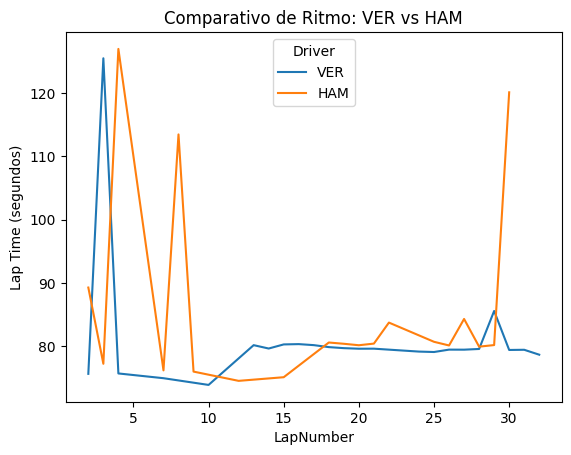

In [11]:
drivers = ['VER', 'HAM']
df_comp = df[df['Driver'].isin(drivers)]
sns.lineplot(data=df_comp, x='LapNumber', y=df_comp['LapTime'].dt.total_seconds(), hue='Driver')
plt.title('Comparativo de Ritmo: VER vs HAM')
plt.ylabel('Lap Time (segundos)')
plt.show()

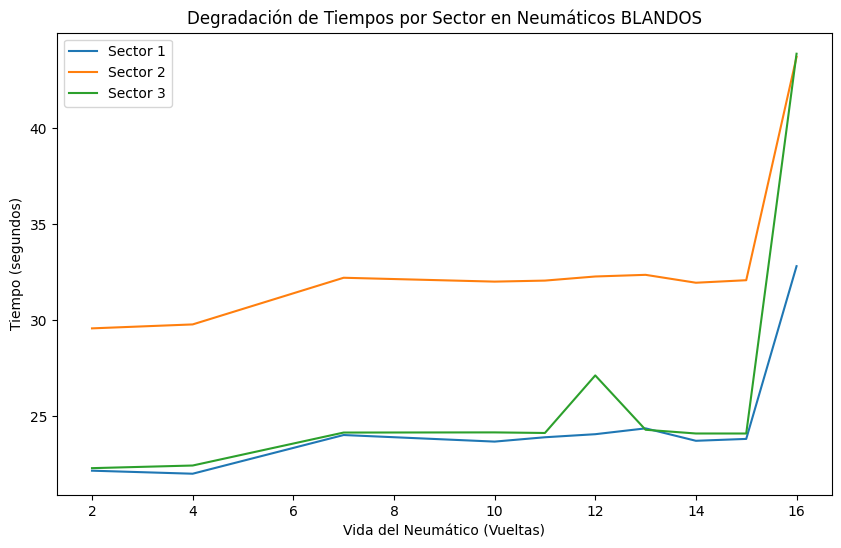

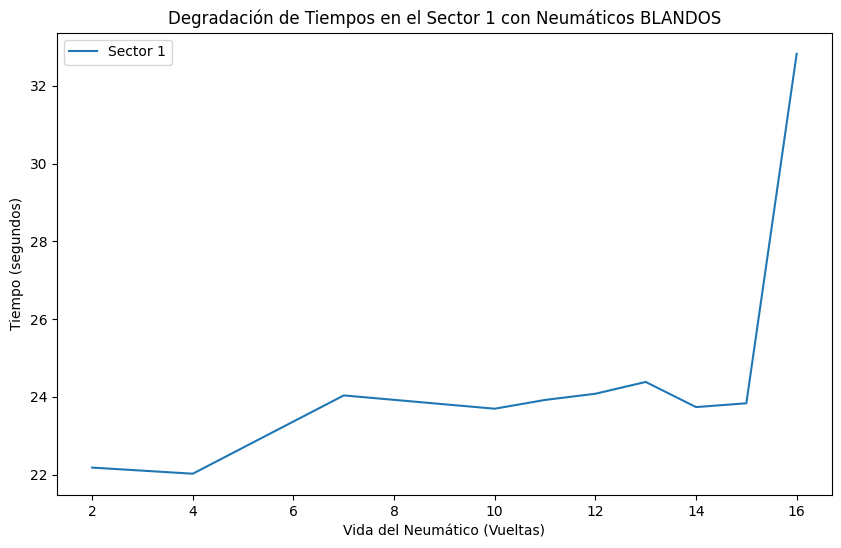

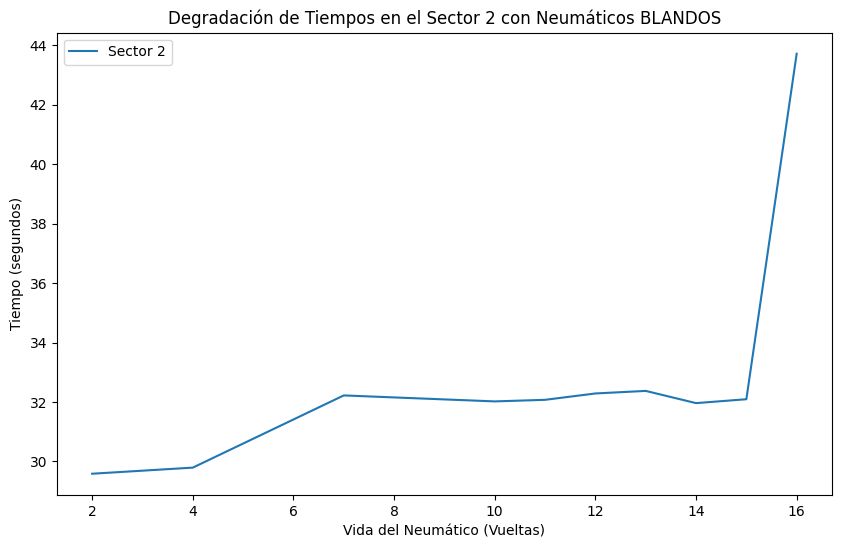

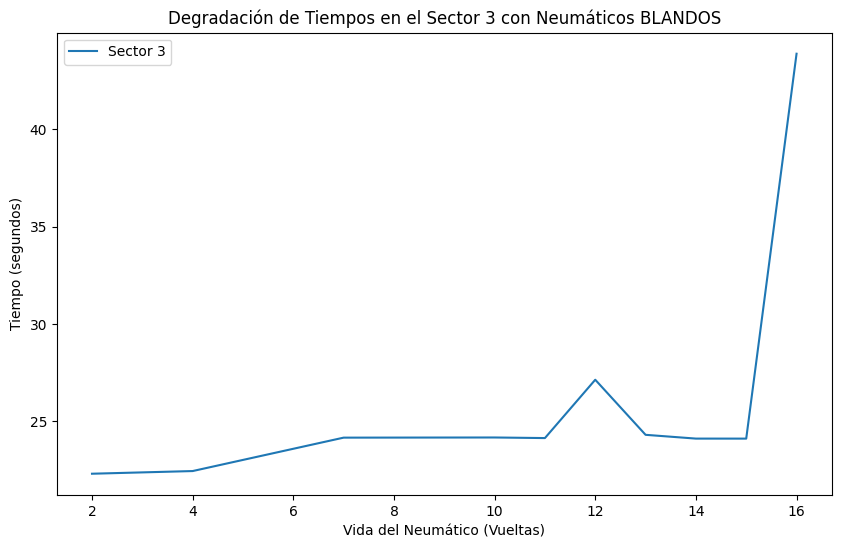

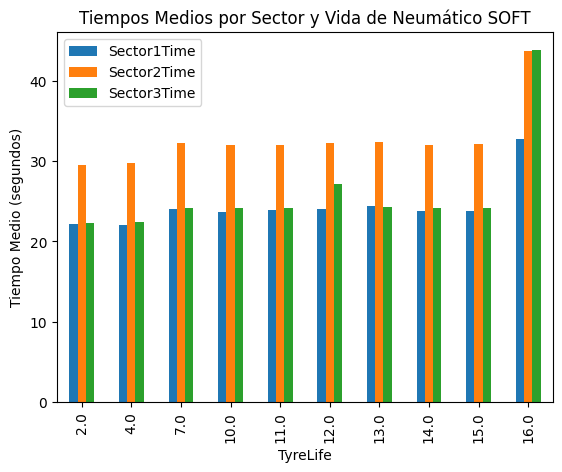

In [13]:
df_soft = df[df['Compound'] == 'SOFT']  # En 2018, SOFT era 'SUPERSOFT' en FastF1
df_soft = df_soft[df_soft['Driver'] == 'ALO']

# Convertir TyreLife a numérico si es necesario
df_soft['TyreLife'] = pd.to_numeric(df_soft['TyreLife'], errors='coerce')

# Plot: Degradación por sector vs. vida del neumático
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_soft, x='TyreLife', y=df_soft['Sector1Time'].dt.total_seconds(), label='Sector 1')
sns.lineplot(data=df_soft, x='TyreLife', y=df_soft['Sector2Time'].dt.total_seconds(), label='Sector 2')
sns.lineplot(data=df_soft, x='TyreLife', y=df_soft['Sector3Time'].dt.total_seconds(), label='Sector 3')
plt.title('Degradación de Tiempos por Sector en Neumáticos BLANDOS')
plt.xlabel('Vida del Neumático (Vueltas)')
plt.ylabel('Tiempo (segundos)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_soft, x='TyreLife', y=df_soft['Sector1Time'].dt.total_seconds(), label='Sector 1')
plt.title('Degradación de Tiempos en el Sector 1 con Neumáticos BLANDOS')
plt.xlabel('Vida del Neumático (Vueltas)')
plt.ylabel('Tiempo (segundos)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_soft, x='TyreLife', y=df_soft['Sector2Time'].dt.total_seconds(), label='Sector 2')
plt.title('Degradación de Tiempos en el Sector 2 con Neumáticos BLANDOS')
plt.xlabel('Vida del Neumático (Vueltas)')
plt.ylabel('Tiempo (segundos)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_soft, x='TyreLife', y=df_soft['Sector3Time'].dt.total_seconds(), label='Sector 3')
plt.title('Degradación de Tiempos en el Sector 3 con Neumáticos BLANDOS')
plt.xlabel('Vida del Neumático (Vueltas)')
plt.ylabel('Tiempo (segundos)')
plt.legend()
plt.show()


# Comparación media: ¿Sector 3 se degrada más?
mean_degrad = df_soft.groupby('TyreLife')[['Sector1Time', 'Sector2Time', 'Sector3Time']].mean().apply(lambda x: x.dt.total_seconds())
mean_degrad.plot(kind='bar')
plt.title('Tiempos Medios por Sector y Vida de Neumático SOFT')
plt.ylabel('Tiempo Medio (segundos)')
plt.show()

<h2>Conversión real de los datos</h2>

In [26]:
df = pd.read_csv('../src/data/2023_Spain_FP2_laps.csv')

time_cols = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']

for col in time_cols:
    df[col] = df[col].apply(str_to_timedelta).dt.total_seconds()

df = df[df['PitInTime'].isna() & df['PitOutTime'].isna()] # Eliminamos las vueltas que sean de salida y entrada de boxes
df = df.dropna(subset=['LapTime'])                        # Aquellas vueltas que no tengan lapTime las borramos


# Interpolamos los valores nulos de las velocidades a lo largo de la vuelta
cols = ['SpeedI1','SpeedI2','SpeedFL','SpeedST']

for col in cols:
    df[col] = df.groupby('Driver')[col].transform(
        lambda x: x.interpolate(limit_direction='both')
)

# Filtrado básico de outliers (IQR en LapTime)
Q1 = df['LapTime'].quantile(0.1)
Q3 = df['LapTime'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['LapTime'] <= (Q3 + 1.5 * IQR))]

df.head(20)

,Driver,Team,LapNumber,LapTime,Sector1Time,Sector2Time,Sector3Time,Compound,TyreLife,TrackStatus,SpeedI1,SpeedI2,SpeedFL,SpeedST,Position,IsPersonalBest,Stint,PitOutTime,PitInTime,Deleted
1,VER,Red Bull Racing,2.0,75.655,22.477,30.330,22.848,TEST_UNKNOWN,2.0,1,283.0,293.0,291.0,323.000000,NaN,True,1.0,NaN,NaN,False
3,VER,Red Bull Racing,4.0,75.718,22.350,30.467,22.901,TEST_UNKNOWN,4.0,1,285.0,303.0,291.0,324.000000,NaN,False,1.0,NaN,NaN,False
6,VER,Red Bull Racing,7.0,74.968,22.268,30.016,22.684,MEDIUM,2.0,1,285.0,302.0,291.0,323.000000,NaN,True,2.0,NaN,NaN,False
9,VER,Red Bull Racing,10.0,73.907,22.000,29.585,22.322,SOFT,2.0,1,286.0,299.0,288.0,322.000000,NaN,True,3.0,NaN,NaN,False
12,VER,Red Bull Racing,13.0,80.186,23.986,32.166,24.034,MEDIUM,5.0,1,255.0,254.0,275.0,299.000000,NaN,False,4.0,NaN,NaN,False
13,VER,Red Bull Racing,14.0,79.654,23.923,32.012,23.719,MEDIUM,6.0,1,259.0,264.0,277.0,300.000000,NaN,False,4.0,NaN,NaN,False
14,VER,Red Bull Racing,15.0,80.302,24.099,32.076,24.127,MEDIUM,7.0,1,255.0,261.0,274.0,301.000000,NaN,False,4.0,NaN,NaN,False
15,VER,Red Bull Racing,16.0,80.349,24.084,32.191,24.074,MEDIUM,8.0,1,253.0,264.0,275.0,303.000000,NaN,False,4.0,NaN,NaN,False
16,VER,Red Bull Racing,17.0,80.189,23.926,32.159,24.104,MEDIUM,9.0,1,250.0,261.0,277.0,302.500000,NaN,False,4.0,NaN,NaN,False
17,VER,Red Bull Racing,18.0,79.877,23.843,32.021,24.013,MEDIUM,10.0,1,256.0,267.0,277.0,302.000000,NaN,False,4.0,NaN,NaN,False


In [21]:
print("\nNulos por columna:", df.isnull().sum())


Nulos por columna: Driver              0
Team                0
LapNumber           0
LapTime             0
Sector1Time         0
Sector2Time         0
Sector3Time         0
Compound            0
TyreLife            0
TrackStatus         0
SpeedI1             0
SpeedI2             0
SpeedFL             0
SpeedST             0
Position          349
IsPersonalBest      0
Stint               0
PitOutTime        349
PitInTime         349
Deleted             0
dtype: int64


In [22]:
df = df.drop(['PitOutTime','PitInTime'], axis=1)

df

,Driver,Team,LapNumber,LapTime,Sector1Time,Sector2Time,Sector3Time,Compound,TyreLife,TrackStatus,SpeedI1,SpeedI2,SpeedFL,SpeedST,Position,IsPersonalBest,Stint,Deleted
1,VER,Red Bull Racing,2.0,75.655,22.477,30.330,22.848,TEST_UNKNOWN,2.0,1,283.0,293.0,291.0,323.0,NaN,True,1.0,False
3,VER,Red Bull Racing,4.0,75.718,22.350,30.467,22.901,TEST_UNKNOWN,4.0,1,285.0,303.0,291.0,324.0,NaN,False,1.0,False
6,VER,Red Bull Racing,7.0,74.968,22.268,30.016,22.684,MEDIUM,2.0,1,285.0,302.0,291.0,323.0,NaN,True,2.0,False
9,VER,Red Bull Racing,10.0,73.907,22.000,29.585,22.322,SOFT,2.0,1,286.0,299.0,288.0,322.0,NaN,True,3.0,False
12,VER,Red Bull Racing,13.0,80.186,23.986,32.166,24.034,MEDIUM,5.0,1,255.0,254.0,275.0,299.0,NaN,False,4.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,PIA,McLaren,22.0,80.672,24.195,32.312,24.165,SOFT,11.0,1,269.0,265.0,279.0,298.0,NaN,False,4.0,False
610,PIA,McLaren,23.0,80.842,24.140,32.479,24.223,SOFT,12.0,1,266.0,269.0,274.0,324.0,NaN,False,4.0,False
611,PIA,McLaren,24.0,81.269,24.280,32.614,24.375,SOFT,13.0,1,259.0,265.0,272.0,300.0,NaN,False,4.0,False
612,PIA,McLaren,25.0,81.219,24.410,32.563,24.246,SOFT,14.0,1,266.0,266.0,281.0,299.0,NaN,False,4.0,False


Driver -> Categoric

Team -> Categoric

LapNumber, LapTime, Sector1Time, Sector2Time, Sector3Time -> Numeric

Compound -> Categoric

TyreLife -> Numeric

TrackStatus -> Categoric

SpeedI1	SpeedI2	SpeedFL	SpeedST	Position -> Numeric

IsPersonalBest -> Binary prob categoric

Stint -> Numeric

Deleted -> Binary prob categoric